In [2]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Load dataset

df = pd.read_csv("medical cost dataset.csv")

# Display first 5 rows
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Dataset information

print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

Shape of Dataset: (1338, 7)

Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
# Check missing values

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
# Statistical summary

df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


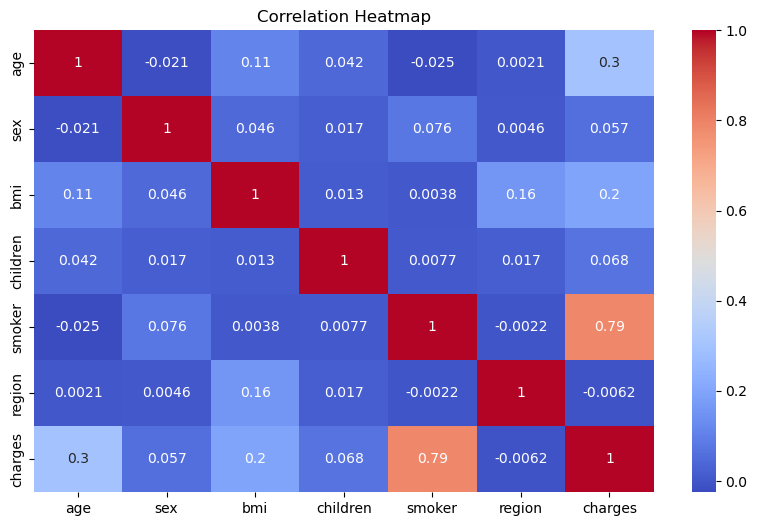

In [7]:
# Convert categorical columns into numerical values for correlation

temp_df = df.copy()

temp_df['sex'] = temp_df['sex'].map({'male':1, 'female':0})
temp_df['smoker'] = temp_df['smoker'].map({'yes':1, 'no':0})
temp_df['region'] = temp_df['region'].astype('category').cat.codes

# Correlation heatmap

plt.figure(figsize=(10,6))

sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

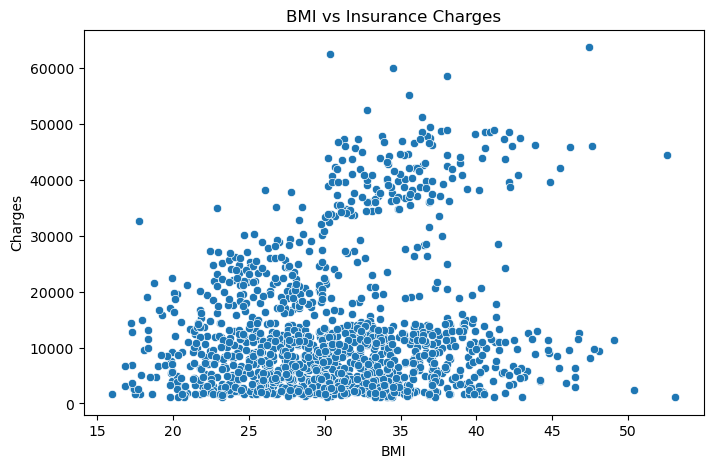

In [8]:
# BMI vs Charges

plt.figure(figsize=(8,5))

sns.scatterplot(x='bmi', y='charges', data=df)

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")

plt.show()

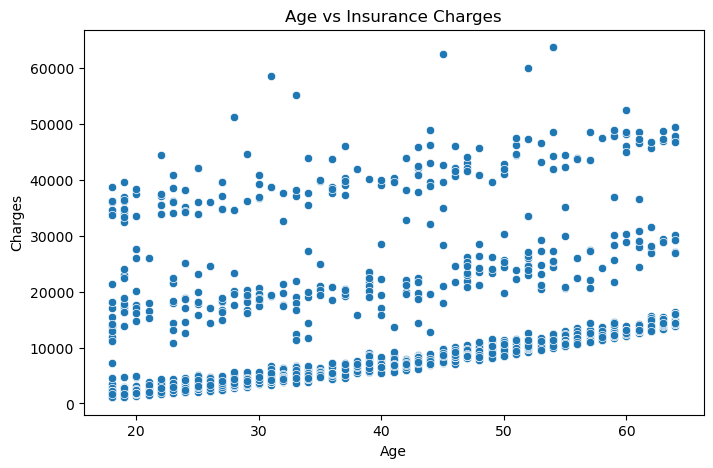

In [9]:
# Age vs Charges

plt.figure(figsize=(8,5))

sns.scatterplot(x='age', y='charges', data=df)

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Charges")

plt.show()

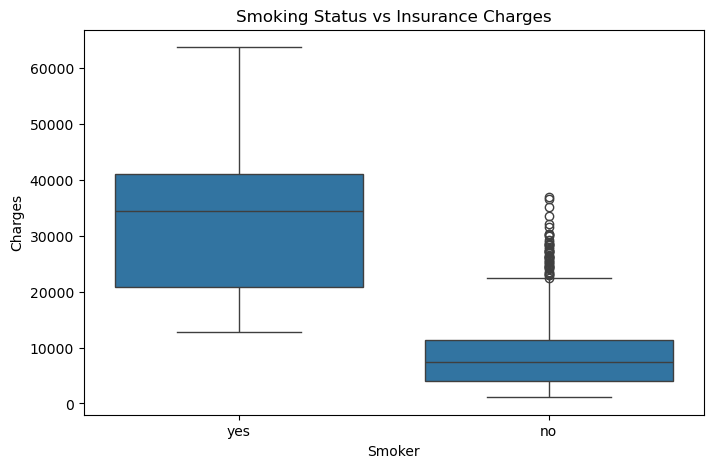

In [10]:
# Smoking Status vs Charges

plt.figure(figsize=(8,5))

sns.boxplot(x='smoker', y='charges', data=df)

plt.title("Smoking Status vs Insurance Charges")
plt.xlabel("Smoker")
plt.ylabel("Charges")

plt.show()

In [11]:
# Convert categorical variables using one-hot encoding

df_encoded = pd.get_dummies(df, drop_first=True)

# Display first rows
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [12]:
# Features (X) and Target (y)

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1338, 8)
Target Shape: (1338,)


In [13]:
# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (1070, 8)
Testing Data Shape: (268, 8)


In [14]:
# Create and train Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [15]:
# Predict insurance charges

y_pred = model.predict(X_test)

# Display first 5 predictions

predictions = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

predictions.head()

,Actual,Predicted
0,9095.06825,8969.550274
1,5272.17580,7068.747443
2,29330.98315,36858.410912
3,9301.89355,9454.678501
4,33750.29180,26973.173457


In [16]:
# Calculate MAE and RMSE

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):", mae)

print("Root Mean Squared Error (RMSE):", rmse)

Mean Absolute Error (MAE): 4181.1944737536505
Root Mean Squared Error (RMSE): 5796.2846592762735


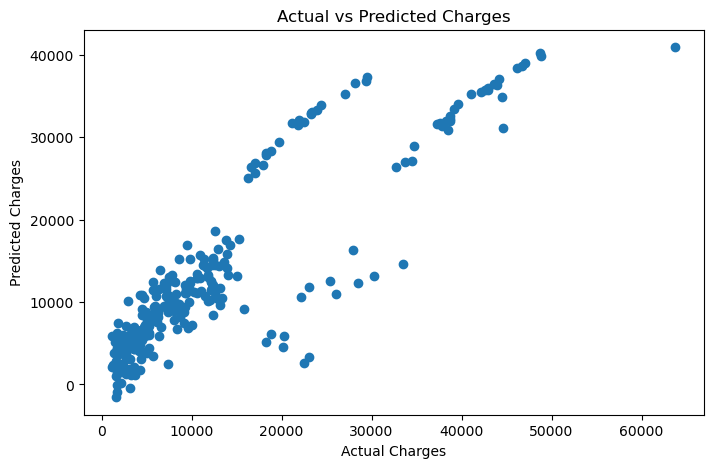

In [17]:
# Actual vs Predicted Charges

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.show()